In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots



%matplotlib inline

IndentationError: expected an indented block (bootstrap.py, line 69)

# Initialize test run and set

In [ ]:
# pattern = '/Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/FieldScan_Gate0576_Anode1576/RUN32_20260702_Gate0576_Anode1576_P4'
# files = glob.glob(f"{pattern}*.wfm")
# filenames = [os.path.basename(f) for f in files]
# for i, file in enumerate(files):
#     os.rename(file, f"{pattern}_{i}Wfm.wfm")    

In [3]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run32_analysis.yaml'

bare_run = bootstrap_from_config(config_path)

NameError: name 'bootstrap_from_config' is not defined

In [4]:
set0 = bare_run.sets[0]
print(set0)

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_before
  filenames = <20 files, 9860 waveforms, FastFrame(493 frames/file)>
  multiiso = True
  ff = True
  nframes = 493

  Missing:
    target_isotope, gate, anode, sampling_rate, drift_field, EL_field, red_drift_field, red_EL_field, speed_drift, time_drift, diffusion_coefficient, baseline_median, baseline_std, t_s1, t_s1_std, t_s2_start, t_s2_start_std, t_s2_end, t_s2_end_std, filtered_drift_time, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success, s2_background_bound


# Set drift properties

In [8]:
run = map_drift_physics(bare_run, force=False)
set0 = run.sets[0]

  ⚠ Item 1 failed: Cannot run 'set_fields' on /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_before. Missing required attributes: ['gate', 'anode']
  ⚠ Item 2 failed: Cannot run 'set_fields' on /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V. Missing required attributes: ['gate', 'anode']
  ⚠ Item 3 failed: Cannot run 'set_fields' on /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V_batch2. Missing required attributes: ['gate', 'anode']
  ⚠ Item 4 failed: Cannot run 'set_fields' on /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V_batch3. Missing required attributes: ['gate', 'anode']
  ⚠ Item 5 failed: Cannot run 'set_fields' on /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V_batch4. Missing required attributes: ['gate', 'anode']
  ⚠ Item 6 failed: Cannot run 'set_fields' on /Volumes/KINGSTON/RaTag_data/raw_waveform

In [7]:
set0

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/FieldScan_Gate0120_Anode1120
  filenames = <40 files, 19720 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493
  gate = 120
  anode = 1120
  drift_field = 250.0
  EL_field = 25000.0
  red_drift_field = 1.025
  red_EL_field = 102.513
  speed_drift = 1.329
  time_drift = 3.611
  t_s1 = -2.717
  t_s1_std = 0.397
  t_s2_start = -0.059
  t_s2_start_std = 1.038
  t_s2_end = 0.894
  t_s2_end_std = 0.273
  n_areas_recoil = 2798
  area_s2_mean = 13.607
  area_s2_sigma = 5.621
  area_s2_ci95 = 0.415
  area_s2_fit_success = True
  s2_background_bound = 8.25

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std

In [129]:
for s in run.sets:
    print(s.speed_drift, s.time_drift)

1.329 3.611
1.388 3.459
1.482 3.238
1.535 3.126
1.597 3.006
1.652 2.906
1.773 2.707
1.868 2.57
1.943 2.47
2.005 2.394
2.057 2.334


# Test new timing_workflow

## Debug for Individual sets

In [15]:
from RaTag.plotting import plot_waveform, plot_frames, plot_random_frames
from RaTag.core.dataIO import load_wfm
from RaTag.io.file_ops import iter_waveforms, iter_frames
from RaTag.waveform.preprocessing import subtract_pedestal, moving_average, threshold_clip
from RaTag.thgem_tpc.timing_workflow import find_s1, find_s2

In [12]:
set8 = run.sets[6]
set8t = resolve_set_timing(set8, max_frames=1200, config=TimingConfig(), force=False)

  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0384_Anode1284'


In [10]:
out_s1 = []
for wf in iter_waveforms(set8, max_files=3):
    t_s1 = find_s1(wf, config=TimingConfig())
    out_s1.append(t_s1)
out_s1 = np.concatenate(out_s1)

In [11]:
set8 = run.sets[6]
fileidx = 0
frameidx = 0
wf = load_wfm(set8.source_dir / set8.filenames[fileidx])

(<Figure size 1000x1600 with 4 Axes>,
 array([<Axes: title={'center': 'Waveform, File 35, frame 144 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
        <Axes: title={'center': 'Waveform, File 16, frame 8 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
        <Axes: title={'center': 'Waveform, File 10, frame 303 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
        <Axes: title={'center': 'Waveform, File 35, frame 478 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>],
       dtype=object))

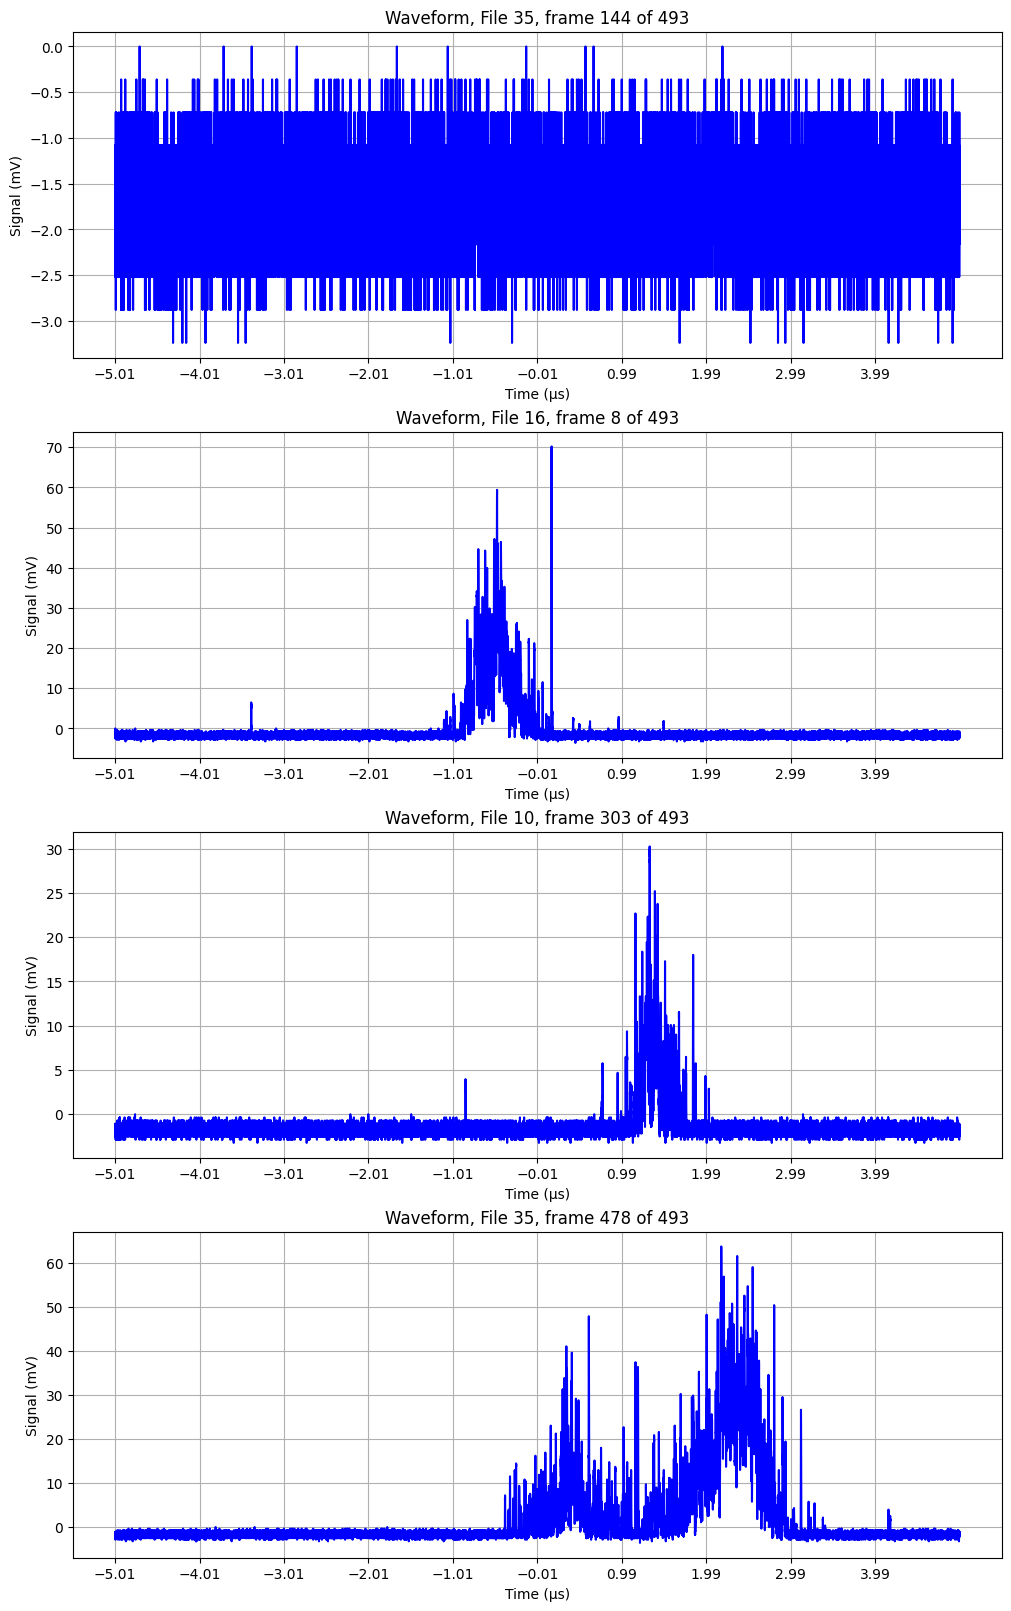

In [18]:
plot_random_frames(set8, n_frames=4, )

In [13]:
set8t.filenames[19]

'RUN32_20260702_Gate0384_Anode1384_P6_28Wfm.wfm'

## Full run

In [42]:
runt = map_time_windows(run, max_frames=1200, config=TimingConfig(), force=False)

  ✓ FieldScan_Gate0120_Anode1020: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0144_Anode1044: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0188_Anode1088: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0216_Anode1116: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0252_Anode1152: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0288_Anode1188: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0384_Anode1284: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0480_Anode1380: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0576_Anode1476: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0672_Anode1572: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0768_Anode1668: Computed 't_s2_end' and stored metadata


## Plot timing results

In [43]:
runt = map_timing_plots(runt, force=True)


GENERATING TIMING PLOTS: RUN_33
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN33_EL22p5k/plots/timing_qa/RUN_33_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN33_EL22p5k/plots/timing_qa/RUN_33_validation.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN33_EL22p5k/plots/timing_qa/RUN_33_timing_vs_field.png


In [46]:
set11t = runt.sets[11]
set11t

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN31_EL20k/FieldScan_Gate0576_Anode1376
  filenames = <40 files, 19720 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493
  gate = 576
  anode = 1376
  drift_field = 1200.0
  EL_field = 20000.0
  red_drift_field = 4.921
  red_EL_field = 82.011
  speed_drift = 1.943
  time_drift = 2.47
  t_s1 = -2.513
  t_s1_std = 0.754
  t_s2_start = -0.427
  t_s2_start_std = 0.187
  t_s2_end = 2.228
  t_s2_end_std = 1.203

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success

# Integration pipeline

In [44]:
integ_dict = {
    'n_sigma_start': 2,
    'n_sigma_end': 2,
    'n_pedestal': 200,
    'ma_window': 9,
    'bs_threshold': 0.03,
    'dt': 2e-4
}

integ_config = IntegrationConfig(**integ_dict)

In [ ]:
runi = map_recoil_integration(runt, max_frames=None, config=integ_config, force=False)


INTEGRATING S2 RECOILS: RUN_33
  Integrating set FieldScan_Gate0120_Anode1020 with Static Window: [-2.06, 7.05] µs
  🔹 Processed 40 waveforms for S2 area integration.
  ✓ FieldScan_Gate0120_Anode1020: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0144_Anode1044 with Static Window: [-2.26, 1.91] µs
  🔹 Processed 40 waveforms for S2 area integration.
  ✓ FieldScan_Gate0144_Anode1044: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0188_Anode1088 with Static Window: [-2.42, 3.14] µs
  🔹 Processed 40 waveforms for S2 area integration.
  ✓ FieldScan_Gate0188_Anode1088: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0216_Anode1116 with Static Window: [-2.51, 1.02] µs
  🔹 Processed 80 waveforms for S2 area integration.
  ✓ FieldScan_Gate0216_Anode1116: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0252_Anode1152 with Static Window: [-2.75, 2.45] µs
  🔹 Processed 40 wav

## Fits s2 area histograms

### Single set debug

In [18]:
from RaTag.core.paths import get_output_root
from RaTag.el_tpc.fit_s2_area import v_crystalball_right
from RaTag.io.file_ops import load_fit_result, load_s2areas
from RaTag.plotting import plot_s2areas_summary

In [30]:
set8i.source_dir.name

'FieldScan_Gate0576_Anode1576'

In [35]:
counts, bins = np.histogram(s2_areas.areas, bins=100, range=(3, 50))
cbins = 0.5 * (bins[1:] + bins[:-1])
n_smooth1 = np.convolve(counts, np.ones(1)/1, mode='same')
n_smooth2 = np.convolve(counts, np.ones(2)/2, mode='same')
n_smooth3 = np.convolve(counts, np.ones(3)/3, mode='same')


In [19]:
set8i = runi.sets[8]
s2_areas = load_s2areas(set8i)
fit_path = get_output_root(set8i.source_dir.parent) / "fits" / f"{set8i.source_dir.name}_s2_areas_hist_fit.json"
fit_model = load_fit_result(fit_path, funcdefs={'v_crystalball_right': v_crystalball_right})

## Full run

In [46]:
fit_config = FitConfig(
    bin_cuts=(1, 52),
    nbins=100,
    bg_threshold=0.5,
    bg_cutoff=5.0,
    n_sigma=2.5)

runif = map_recoil_fits(runi, config=fit_config, force=True)

map_recoil_plots(runif, config=fit_config, force=True);


FITTING S2 AREA DISTRIBUTIONS: RUN_33
  Fit success: True, χ²/DOF: 254.97
  ✓ Fit: μ=8.330 ± 0.299 mV·µs
  ✓ FieldScan_Gate0120_Anode1020: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 419.58
  ✓ Fit: μ=6.595 ± 0.289 mV·µs
  ✓ FieldScan_Gate0144_Anode1044: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 152.64
  ✓ Fit: μ=8.685 ± 0.300 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0188_Anode1088: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 239.38
  ✓ Fit: μ=7.384 ± 0.477 mV·µs
  ✓ FieldScan_Gate0216_Anode1116: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 139.67
  ✓ Fit: μ=9.201 ± 0.312 mV·µs
  ✓ FieldScan_Gate0252_Anode1152: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 513.23
  ✓ Fit: μ=10.798 ± 0.289 mV·µs
  ✓ FieldScan_Gate0288_Anode1188: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 524.35
  ✓ Fit: μ=10.328 ± 0.289 mV·µs
  ✓ FieldScan_Gate0384_Anode1284: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 362.27
  ✓ Fit: μ=9.746 ± 0.289 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0480_Anode1380: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 718.69
  ✓ Fit: μ=10.156 ± 0.289 mV·µs
  ✓ FieldScan_Gate0576_Anode1476: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 346.19
  ✓ Fit: μ=11.607 ± 0.316 mV·µs
  ✓ FieldScan_Gate0672_Anode1572: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 665.75
  ✓ Fit: μ=10.602 ± 0.289 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0768_Anode1668: Computed 'area_s2_fit_success' and stored metadata

GENERATING RECOIL S2 AREAS QA PLOTS: RUN_33
  Loaded fit model for FieldScan_Gate0120_Anode1020 with lower_bound=2.2750000000000004
Set FieldScan_Gate0120_Anode1020: lower_bound=2.2750000000000004
  Loaded fit model for FieldScan_Gate0144_Anode1044 with lower_bound=2.785
Set FieldScan_Gate0144_Anode1044: lower_bound=2.785
  Loaded fit model for FieldScan_Gate0188_Anode1088 with lower_bound=2.2750000000000004
Set FieldScan_Gate0188_Anode1088: lower_bound=2.2750000000000004
  Loaded fit model for FieldScan_Gate0216_Anode1116 with lower_bound=4.825
Set FieldScan_Gate0216_Anode1116: lower_bound=4.825
  Loaded fit model for FieldScan_Gate0252_Anode1152 with lower_bound=3.295
Set FieldScan_Gate0252_Anode1152: lower_bound=3.295
  Loaded fit model for FieldScan_Gate0288_Anode1188 with lower_bound=2.785
Set FieldScan_Gate0288_Anode1188: lower_bound=2.785
  Loaded fit model for FieldScan_Gate0384_Anode1284 with

# New coincidence workflow

In [98]:
from RaTag.thgem_tpc.coincidence_workflow import (map_coincidence_extraction, resolve_set_coincidence,
                                                   map_filter_drift_time, resolve_drift_time_filter)
from RaTag.thgem_tpc.recoil_workflow import resolve_set_s2_fit
from RaTag.el_tpc.fit_s2_area import fit_s2_crystalball
from RaTag.io.file_ops import (load_fit_result, load_s2areas,
                                load_s2areas_from_path, load_s1areas,
                                  load_npz_arrays,load_waveform_by_uid,
                                  extract_single_frame)

### Single set debug

In [10]:
set8 = run.sets[9]
set8c = resolve_set_coincidence(set8, max_frames=None, config=TimingConfig(), force=False)

  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0672_Anode1672'


In [22]:
areas_path = '/Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz'
np.load(areas_path)['area_s2']

array([17.15734112, 10.56059164, 10.35735723, ...,  6.14477341,
       15.4761547 ,  6.81022553])

In [23]:
load_s2areas(set8c)

S2Areas(uids=array([], dtype=float64), areas=array([24.27217239,  9.55324966,  8.45503251, ..., 28.03902433,
       23.86183032, 18.43569687]))

In [24]:
resolve_set_s2_fit(set8c, config=FitConfig(), force=True)

  Fit success: True, χ²/DOF: 8.57
  ✓ Fit: μ=15.000 ± 0.085 mV·µs
  ✓ FieldScan_Gate0576_Anode1576: Computed 'area_s2_fit_success' and stored metadata


SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/FieldScan_Gate0576_Anode1576
  filenames = <40 files, 19720 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493
  gate = 576
  anode = 1576
  drift_field = 1200.0
  EL_field = 25000.0
  red_drift_field = 4.921
  red_EL_field = 102.513
  speed_drift = 1.943
  time_drift = 2.47
  t_s1 = -2.522
  t_s1_std = 0.331
  t_s2_start = -1.359
  t_s2_start_std = 0.687
  t_s2_end = -0.535
  t_s2_end_std = 0.217
  n_areas_recoil = 4062
  area_s2_mean = 14.99999999995286
  area_s2_sigma = 6.007501129823583
  area_s2_ci95 = 0.08487048957087498
  area_s2_fit_success = True
  s2_background_bound = 5.775

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std

### Full run

In [22]:
map_coincidence_extraction(run, config=TimingConfig(), force = True)


EXTRACTING COINCIDENCE DATA: RUN_32
  Iterating FieldScan_Gate0120_Anode1120: 40/40 (100.0%) | ETA: 00:00   
  FieldScan_Gate0120_Anode1120: 1800/19720 events (9.1%)
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0144_Anode1144: 40/40 (100.0%) | ETA: 00:00   
  FieldScan_Gate0144_Anode1144: 1957/19720 events (9.9%)
  ✓ FieldScan_Gate0144_Anode1144: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0188_Anode1188: 40/40 (100.0%) | ETA: 00:00   
  FieldScan_Gate0188_Anode1188: 2093/19720 events (10.6%)
  ✓ FieldScan_Gate0188_Anode1188: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0216_Anode1216: 40/40 (100.0%) | ETA: 00:00   
  FieldScan_Gate0216_Anode1216: 2108/19720 events (10.7%)
  ✓ FieldScan_Gate0216_Anode1216: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0252_Anode1252: 40/40 (100.0%) | ETA: 00:00   
  FieldScan_Gate0252_Anode1252: 2162/19720 event

Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k
  run_id = RUN_32
  el_field = 25000.0
  multiiso = False
  target_isotope = Th228
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <11 SetPmt objects>
  alpha_sets = [SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_before
  filenames = <20 files, 9860 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a, calib_b, calib_c, calib_order, mean_energy_resolution, isotope_ranges_V, isotope_ranges_E, SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V
  filenames = <17 files, 8381 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a

In [100]:
map_filter_drift_time(run, dt_tolerance=0.6, force=True)


FILTERING BY DRIFT TIME (Blob Isolation): RUN_32
  FieldScan_Gate0120_Anode1120: Mode = 3.08 µs, range [2.48, 3.68] | Kept 1344/1345 events (99.9%)
  ✓ FieldScan_Gate0120_Anode1120: Computed 'filtered_drift_time' and stored metadata
  FieldScan_Gate0144_Anode1144: Mode = 3.07 µs, range [2.47, 3.67] | Kept 1451/1454 events (99.8%)
  ✓ FieldScan_Gate0144_Anode1144: Computed 'filtered_drift_time' and stored metadata
  FieldScan_Gate0188_Anode1188: Mode = 2.90 µs, range [2.30, 3.50] | Kept 1497/1497 events (100.0%)
  ✓ FieldScan_Gate0188_Anode1188: Computed 'filtered_drift_time' and stored metadata
  FieldScan_Gate0216_Anode1216: Mode = 2.91 µs, range [2.31, 3.51] | Kept 1515/1516 events (99.9%)
  ✓ FieldScan_Gate0216_Anode1216: Computed 'filtered_drift_time' and stored metadata
  FieldScan_Gate0252_Anode1252: Mode = 2.76 µs, range [2.16, 3.36] | Kept 1528/1528 events (100.0%)
  ✓ FieldScan_Gate0252_Anode1252: Computed 'filtered_drift_time' and stored metadata
  FieldScan_Gate0288_Anode12

Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k
  run_id = RUN_32
  el_field = 25000.0
  multiiso = False
  target_isotope = Th228
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <11 SetPmt objects>
  alpha_sets = [SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_before
  filenames = <20 files, 9860 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a, calib_b, calib_c, calib_order, mean_energy_resolution, isotope_ranges_V, isotope_ranges_E, SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V
  filenames = <17 files, 8381 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a

In [101]:
map_timing_plots(run, force=True)


GENERATING TIMING PLOTS: RUN_32
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/plots/timing_qa/RUN_32_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/plots/timing_qa/RUN_32_validation.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/plots/timing_qa/RUN_32_timing_vs_field.png


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k
  run_id = RUN_32
  el_field = 25000.0
  multiiso = False
  target_isotope = Th228
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <11 SetPmt objects>
  alpha_sets = [SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_before
  filenames = <20 files, 9860 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a, calib_b, calib_c, calib_order, mean_energy_resolution, isotope_ranges_V, isotope_ranges_E, SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/Ch4_SCA_4p0-4p7_rev_field_200V
  filenames = <17 files, 8381 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a

In [19]:
set8 = run.sets[8]
load_s2areas(set8)
# np.load('/Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz')

S2Areas(uids=array([   0,    1,    2, ..., 1027, 1037, 1054]), areas=array([24.27217239,  9.55324966,  8.45503251, ..., 28.03902433,
       23.86183032, 18.43569687]))

In [29]:
from RaTag.core.config import FitConfig
FitConfig()

FitConfig(bin_cuts=(0, 50), nbins=100, bg_threshold=0.3, bg_cutoff=2.0, n_sigma=2.5)

In [113]:
run = map_recoil_fits(run, config=FitConfig(smooth=3), force=True)
run = map_recoil_plots(run, config=FitConfig(), force=True)


FITTING S2 AREA DISTRIBUTIONS: RUN_32
  Fit success: True, χ²/DOF: 6.44
  ✓ Fit: μ=13.955 ± 0.364 mV·µs
  ✓ FieldScan_Gate0120_Anode1120: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 4.58
  ✓ Fit: μ=14.219 ± 0.361 mV·µs
  ✓ FieldScan_Gate0144_Anode1144: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 9.00
  ✓ Fit: μ=15.769 ± 0.283 mV·µs
  ✓ FieldScan_Gate0188_Anode1188: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 4.07
  ✓ Fit: μ=16.342 ± 0.343 mV·µs
  ✓ FieldScan_Gate0216_Anode1216: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 11.39
  ✓ Fit: μ=16.385 ± 0.283 mV·µs
  ✓ FieldScan_Gate0252_Anode1252: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 5.83
  ✓ Fit: μ=17.608 ± 0.395 mV·µs
  ✓ FieldScan_Gate0288_Anode1288: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 6.54
  ✓ Fit: μ=18.966 ± 

## Filter by S1

In [95]:
from RaTag.plotting import (plot_s1_area_distribution, plot_s2_area_distribution,
                             plot_s1_vs_s2_2d, plot_set_s1_vs_drift_time, plot_s2areas_summary)
from RaTag.el_tpc.fit_s2_area import optimize_s1_cut
import math

In [40]:
path = Path('/Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas')
files = list(path.glob('*s2_areas.npz'))


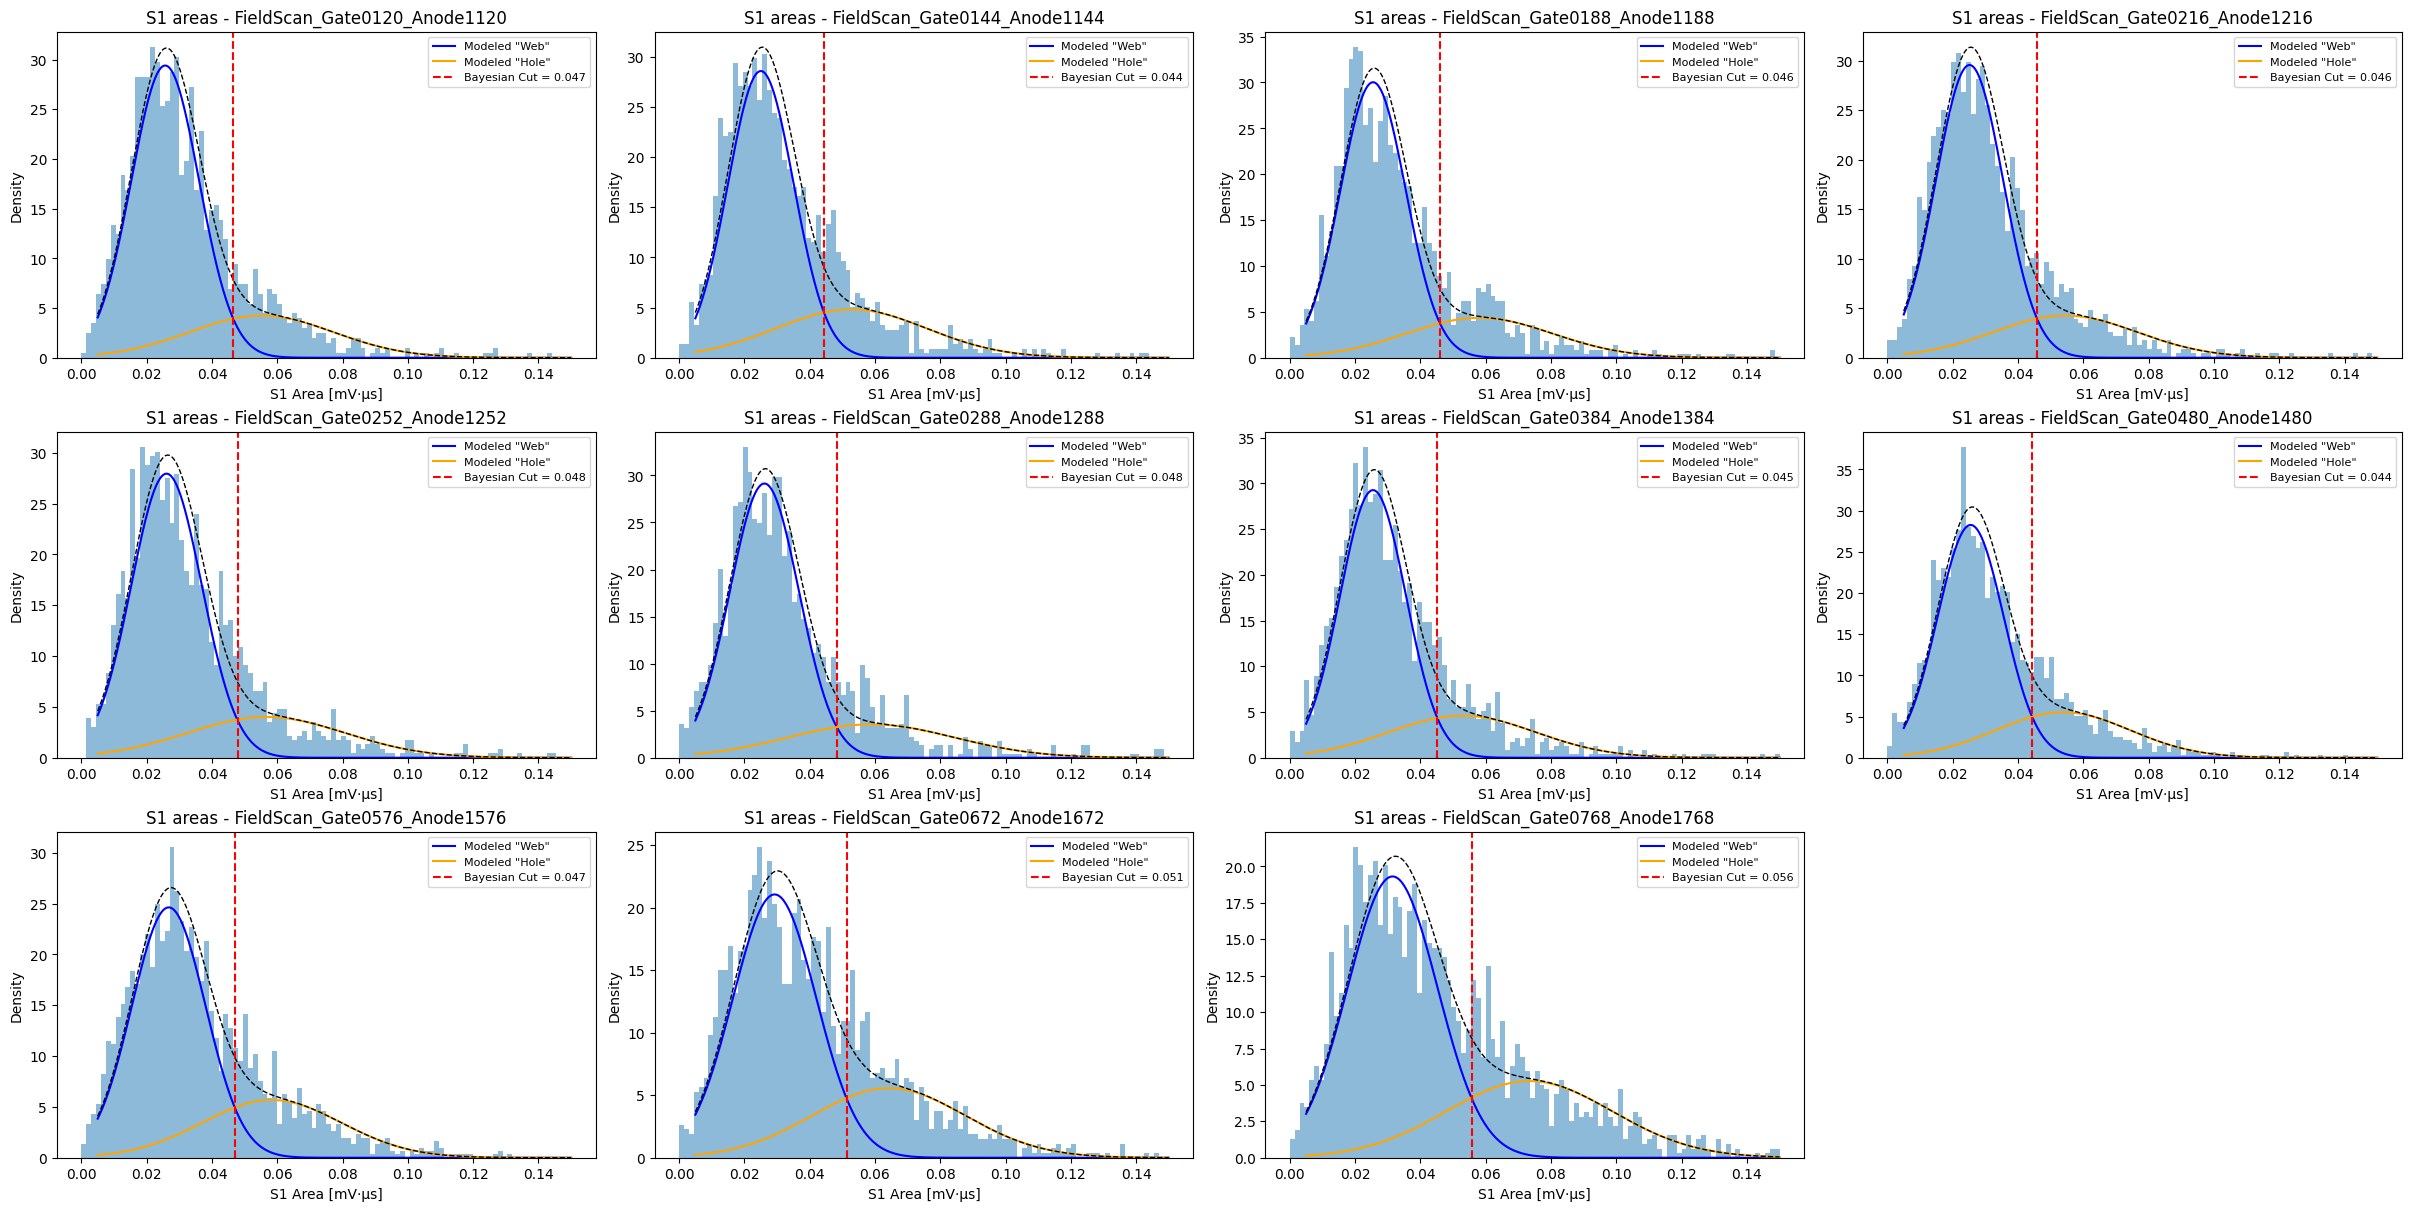

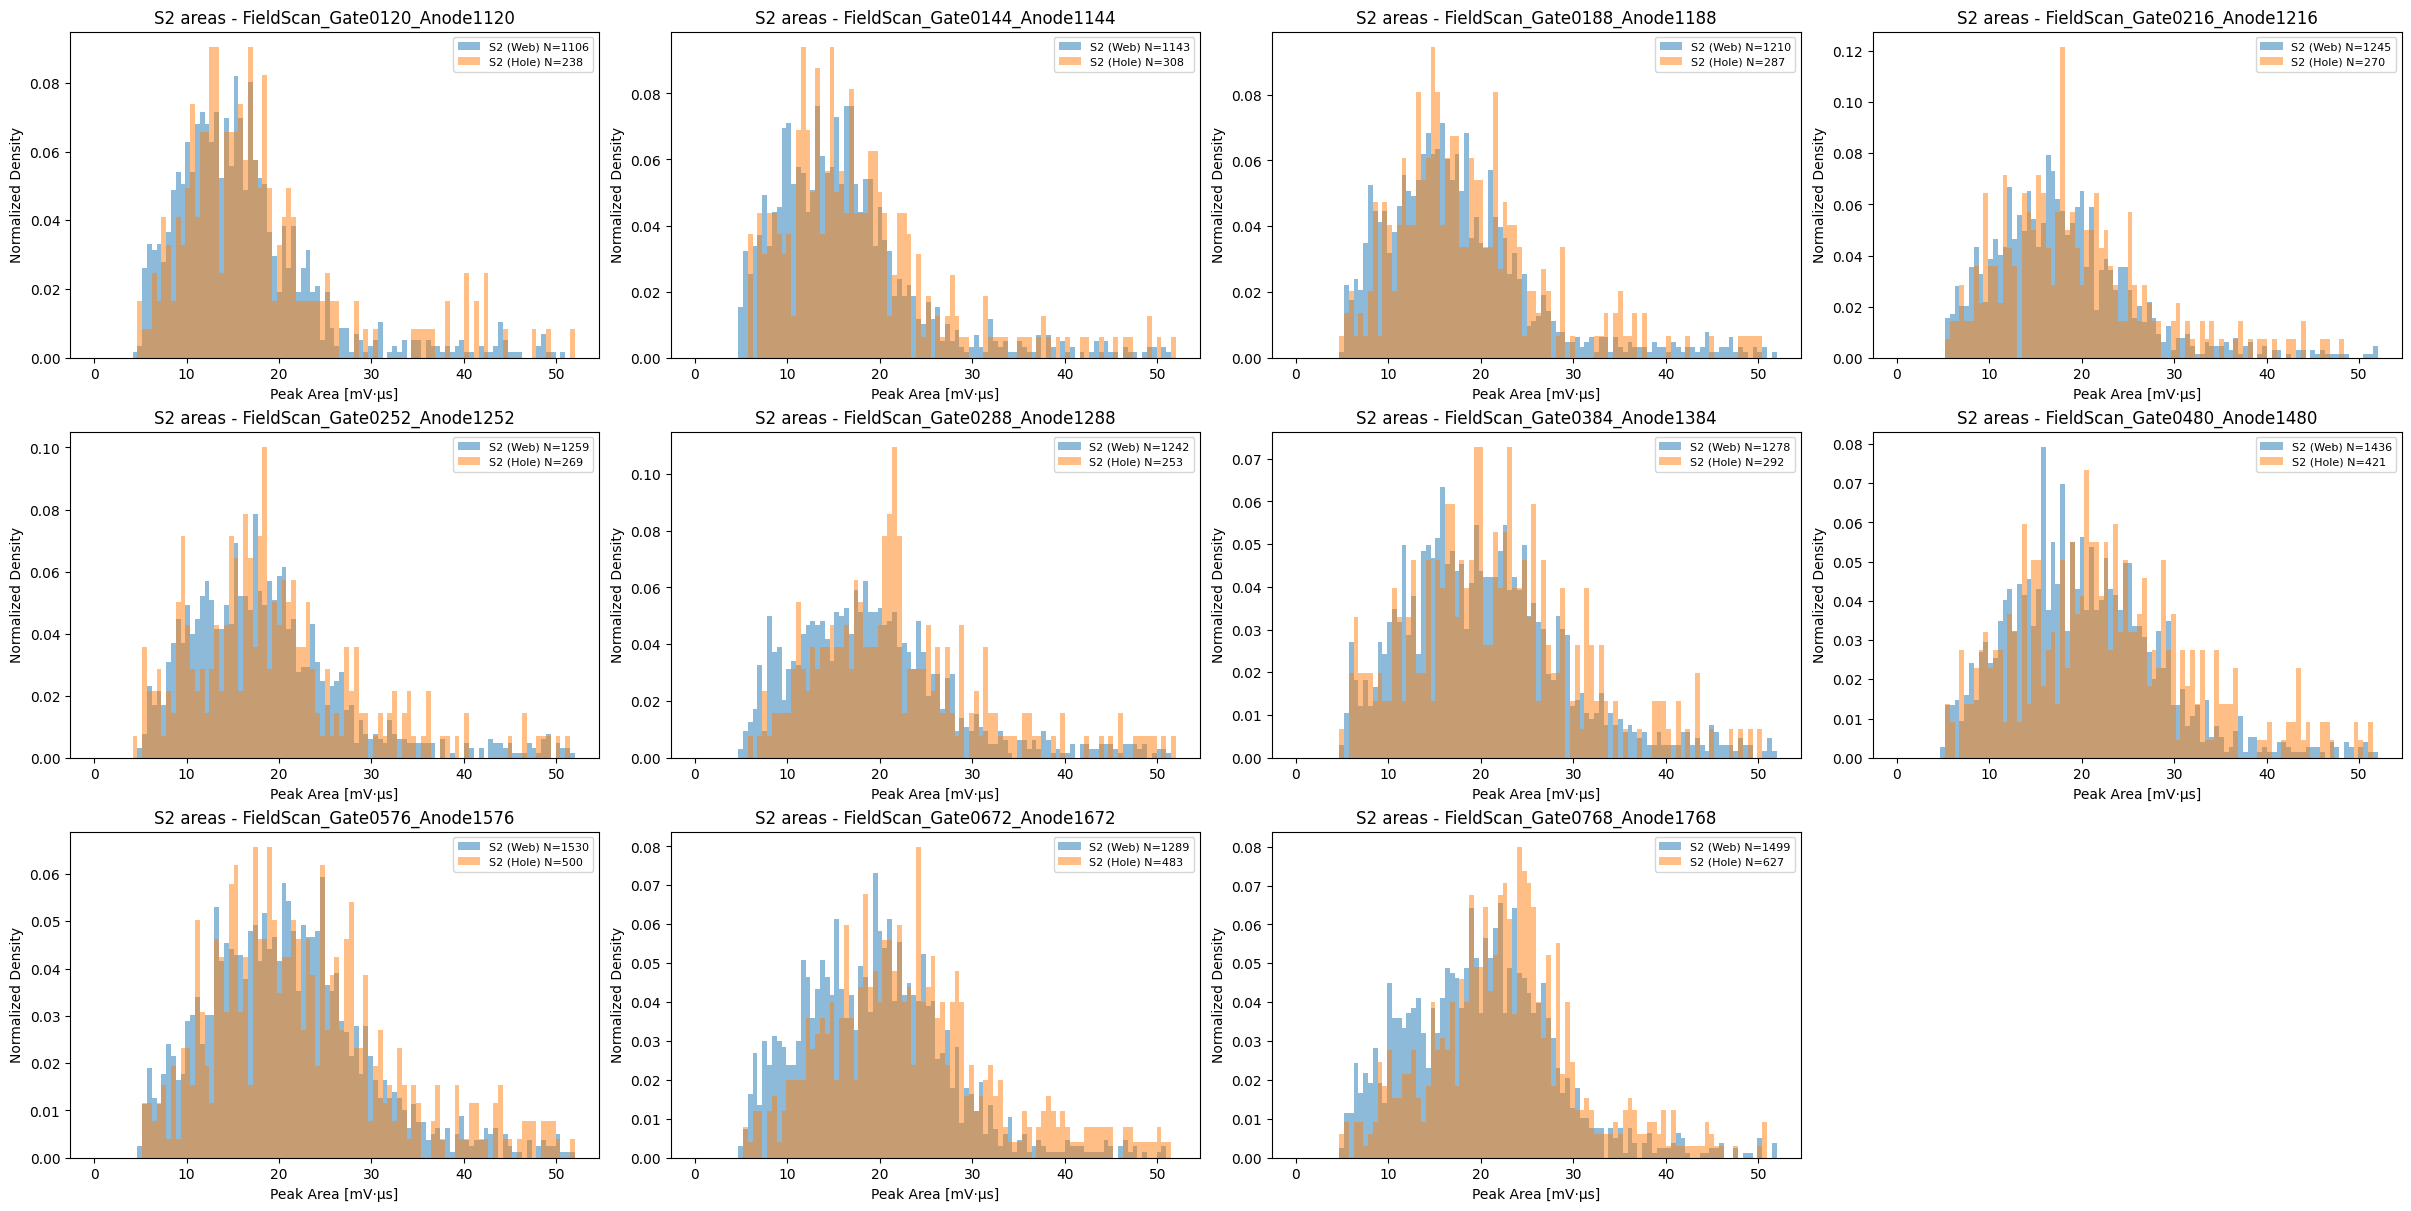

In [106]:
cols = math.ceil(math.sqrt(len(files)))
rows = math.ceil(len(files) / cols) if cols > 0 else 1

# --- To plot S1 Distributions (with GMM fits) ---
fig_s1, ax_s1 = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*6, rows*4), constrained_layout=True)
ax_s1 = np.atleast_2d(ax_s1) # Ensure 2D addressing works even if 1 row

for i, f in enumerate(files):
    row, col = divmod(i, cols)
    plot_s1_area_distribution(f, ax=ax_s1[row, col])

# Turn off empty axes
for j in range(i + 1, rows * cols):
    ax_s1[j // cols, j % cols].axis('off')
    

# --- To plot S2 Distributions (The A/B Test) ---
fig_s2, ax_s2 = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*6, rows*4), constrained_layout=True)
ax_s2 = np.atleast_2d(ax_s2)

for i, f in enumerate(files):
    row, col = divmod(i, cols)
    plot_s2_area_distribution(f, ax=ax_s2[row, col])

for j in range(i + 1, rows * cols):
    ax_s2[j // cols, j % cols].axis('off')

In [50]:
len(files)

11

  Fit success: True, χ²/DOF: 1.68


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


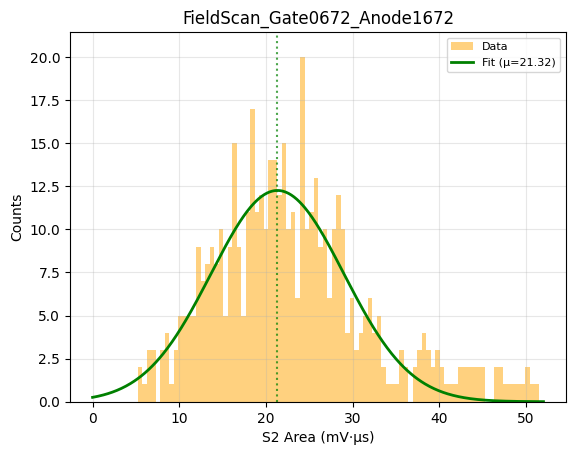

In [107]:
s2_areas_web, s2_areas_tail = plot_s2_area_distribution(files[9], ax=None)
plt.clf()

result9 = fit_s2_crystalball(s2_areas_tail.areas, bin_cuts=(1, 52), nbins=100)

plot_s2areas_summary(ax=plt.gca(), set_name=run.sets[9].source_dir.name, s2_areas=s2_areas_tail, fit_model=result9['result'], bin_cuts=(0, 52))

In [111]:
set9 = run.sets[9]
metadata_updates = {
        'area_s2_mean': result9['peak_position'],
        'area_s2_ci95': result9['ci95'],
        'area_s2_sigma': result9['sigma'],
        'area_s2_fit_success': True,
        's2_background_bound': result9['lower_bound']
    }
set9u = replace(set9, **metadata_updates)
sets = run.sets
sets[9] = set9u
run = replace(run, sets=sets)

  Fit success: True, χ²/DOF: 4.43


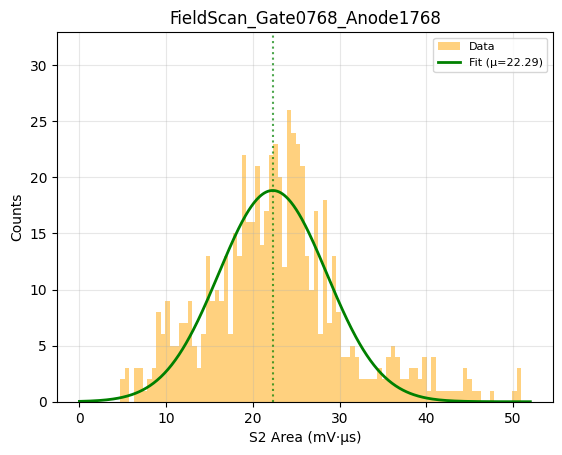

In [108]:
s2_areas_web, s2_areas_tail = plot_s2_area_distribution(files[10], ax=None)
plt.clf()

result10 = fit_s2_crystalball(s2_areas_tail.areas, bin_cuts=(1, 52), nbins=100)

plot_s2areas_summary(ax=plt.gca(), set_name=run.sets[10].source_dir.name, s2_areas=s2_areas_tail, fit_model=result10['result'], bin_cuts=(0, 52))

In [109]:
set9 = run.sets[10]
metadata_updates = {
        'area_s2_mean': result10['peak_position'],
        'area_s2_ci95': result10['ci95'],
        'area_s2_sigma': result10['sigma'],
        'area_s2_fit_success': True,
        's2_background_bound': result10['lower_bound']
    }
set9u = replace(set9, **metadata_updates)
sets = run.sets
sets[10] = set9u
run = replace(run, sets=sets)

In [112]:
run = map_recoil_plots(run, config=FitConfig(), force=True)


GENERATING RECOIL S2 AREAS QA PLOTS: RUN_32
  Loaded fit model for FieldScan_Gate0120_Anode1120 with lower_bound=7.75
  Loaded fit model for FieldScan_Gate0144_Anode1144 with lower_bound=8.25
  Loaded fit model for FieldScan_Gate0188_Anode1188 with lower_bound=8.75
  Loaded fit model for FieldScan_Gate0216_Anode1216 with lower_bound=7.75
  Loaded fit model for FieldScan_Gate0252_Anode1252 with lower_bound=7.25
  Loaded fit model for FieldScan_Gate0288_Anode1288 with lower_bound=6.25
  Loaded fit model for FieldScan_Gate0384_Anode1384 with lower_bound=7.25
  Loaded fit model for FieldScan_Gate0480_Anode1480 with lower_bound=7.25
  Loaded fit model for FieldScan_Gate0576_Anode1576 with lower_bound=9.25
  Loaded fit model for FieldScan_Gate0672_Anode1672 with lower_bound=6.355
  Loaded fit model for FieldScan_Gate0768_Anode1768 with lower_bound=5.845
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/plots/s2_areas/RUN_32_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/

### Other 2D histograms

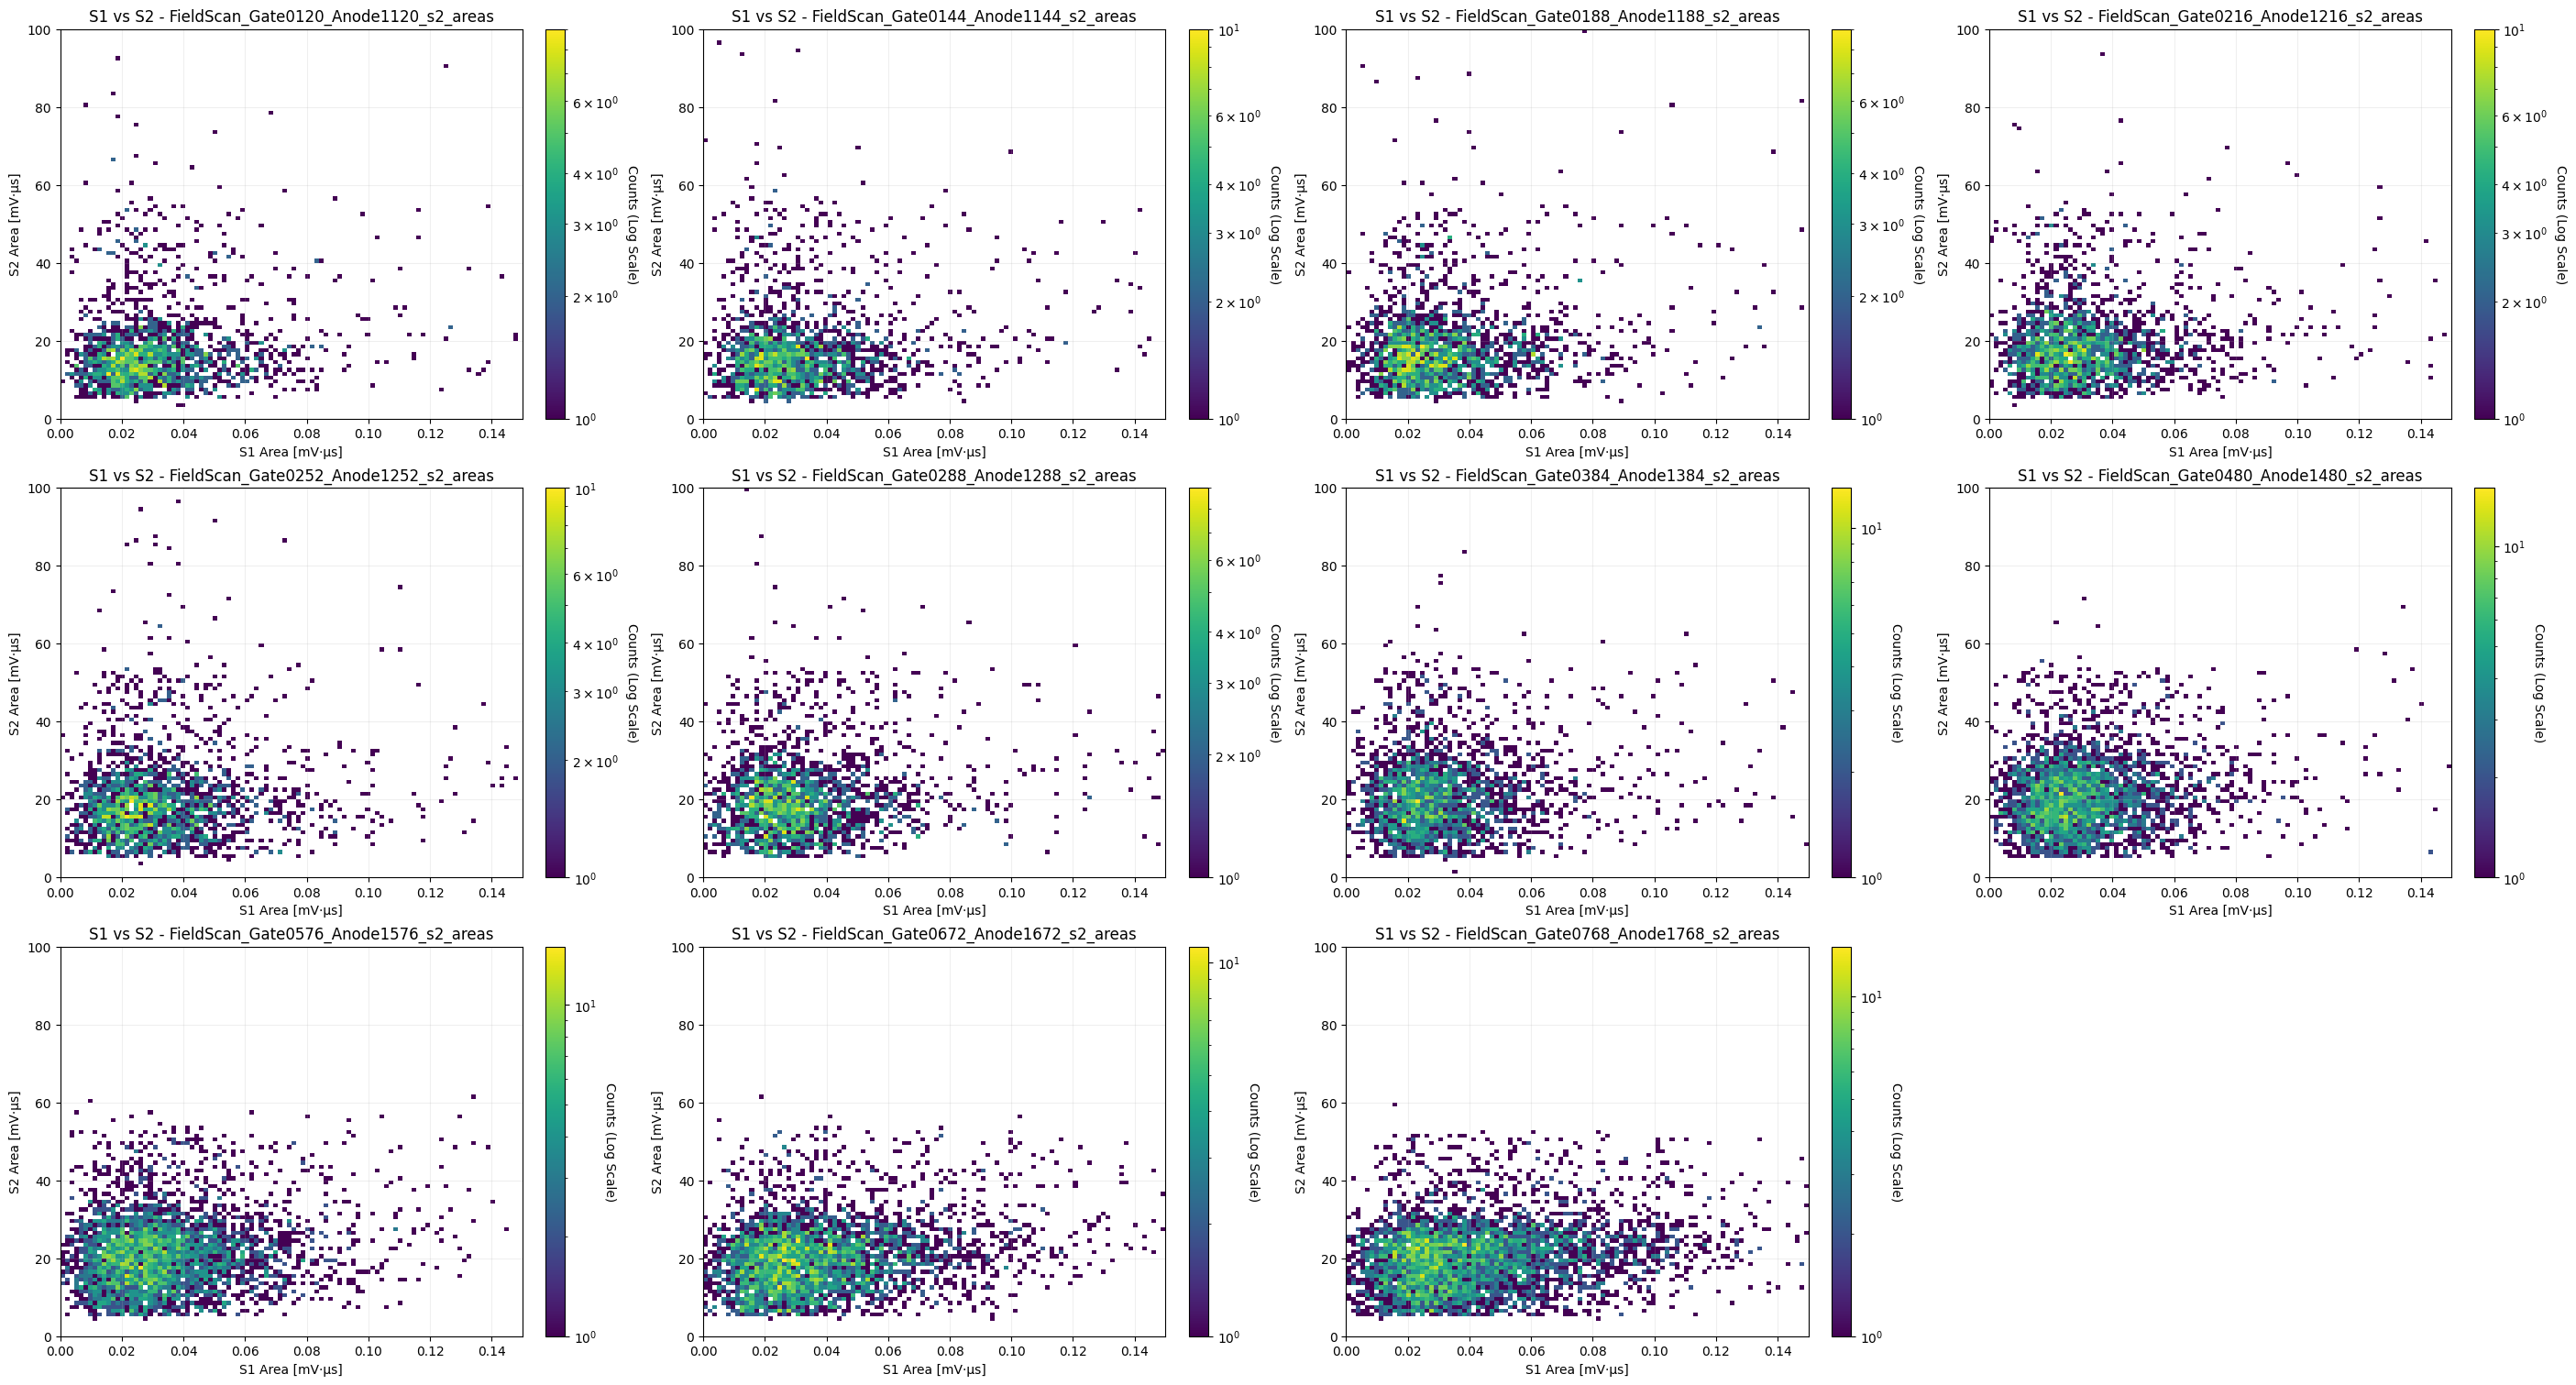

In [ ]:

cols = math.ceil(math.sqrt(len(files)))
rows = math.ceil(len(files) / cols) if cols > 0 else 1

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*7, rows*5), constrained_layout=True)
axes = np.atleast_2d(axes)

for i, f in enumerate(files):
    row, col = divmod(i, cols)
    plot_s1_vs_s2_2d(f, ax=axes[row, col])

for j in range(i + 1, rows * cols):
    axes[j // cols, j % cols].axis('off')
    
plt.show()

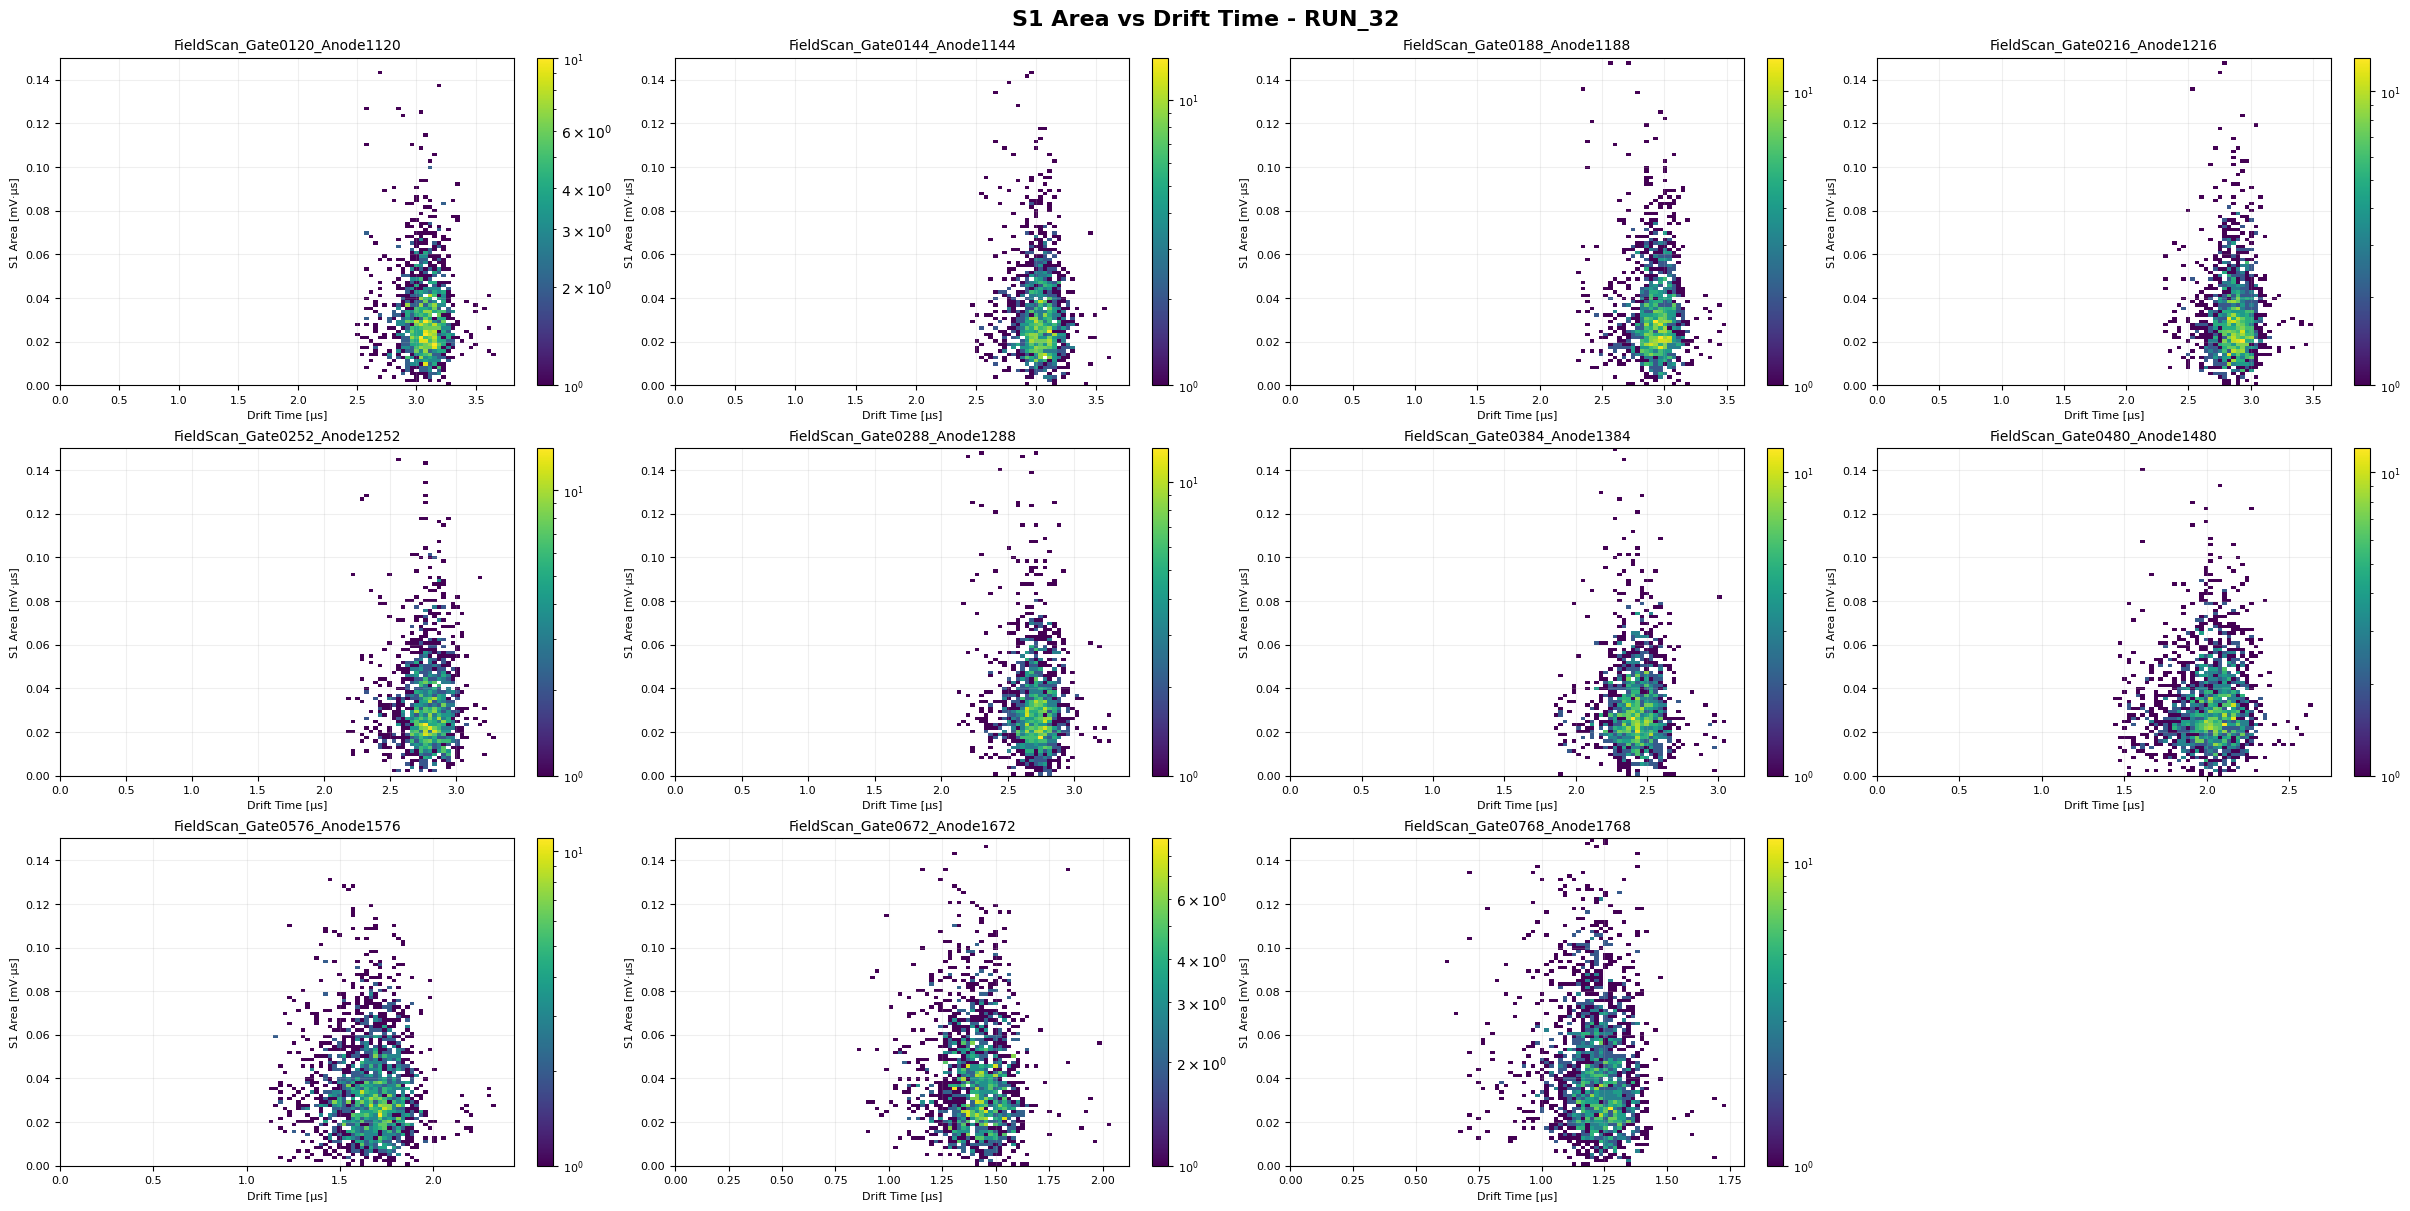

In [104]:
n_sets = len(run.sets)
if n_sets == 0:
    print("No sets found in run.")
    
cols = math.ceil(math.sqrt(n_sets))
rows = math.ceil(n_sets / cols) if cols > 0 else 1

# Build the figure
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*6, rows*4), constrained_layout=True)
axes = np.atleast_2d(axes) # Protect against 1D grids

fig.suptitle(f"S1 Area vs Drift Time - {run.run_id}", fontsize=16, fontweight='bold')

for i, set_pmt in enumerate(run.sets):
    row, col = divmod(i, cols)
    ax = axes[row, col]
    
    success = plot_set_s1_vs_drift_time(set_pmt, ax=ax)
    
    if not success:
        ax.text(0.5, 0.5, "Insufficient Data", ha='center', va='center', color='red')
        ax.set_title(set_pmt.source_dir.name, fontsize=10)
        
# Turn off completely empty axes at the end of the grid
for j in range(i + 1, rows * cols):
    axes[j // cols, j % cols].axis('off')


### Check individual waveforms

In [15]:
from RaTag.plotting import plot_full_coincidence_diagnostic
from RaTag.io.file_ops import load_s1areas, load_npz_arrays, load_waveform_by_uid, extract_single_frame


In [17]:
path = Path('/Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas')
files = list(path.glob('*.npz'))
uids = np.load(files[0])['uids']
set9 = run.sets[0]
files[0], set9.source_dir.name

(PosixPath('/Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz'),
 'Ch4_SCA_4p0-4p7_before')

In [18]:
s1_data = load_s1areas(set9)
timing_data = load_npz_arrays(set9, signal_type='timing')
timing_data

{}

/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  func(*args, **kwargs)
/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


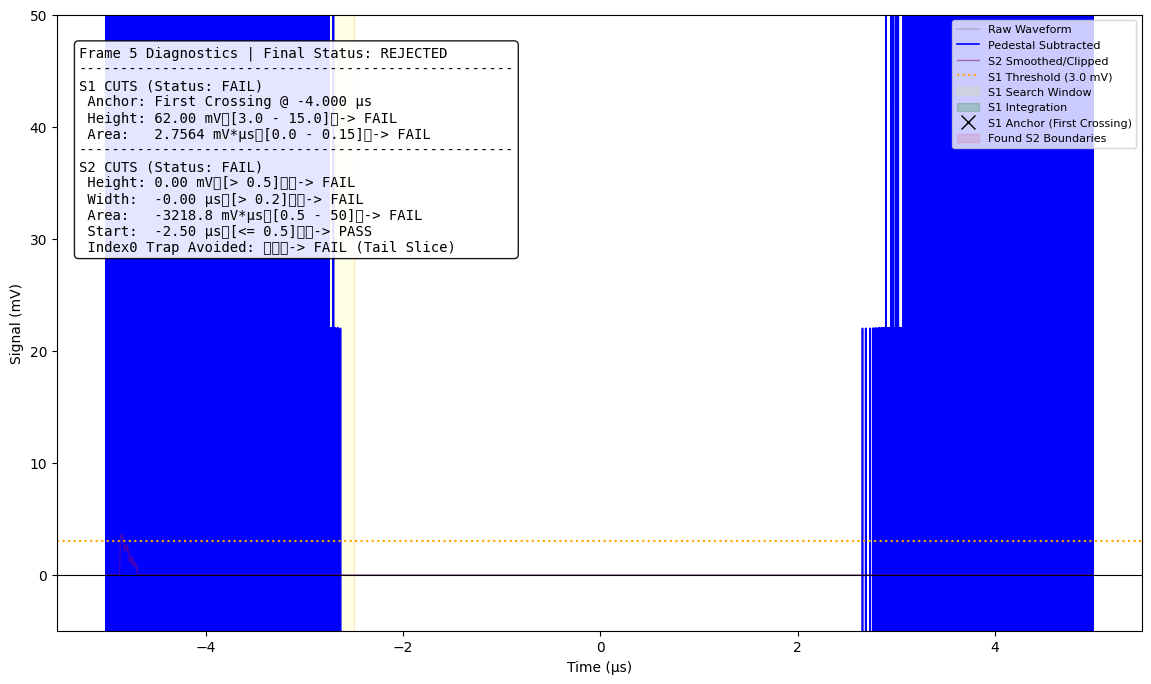

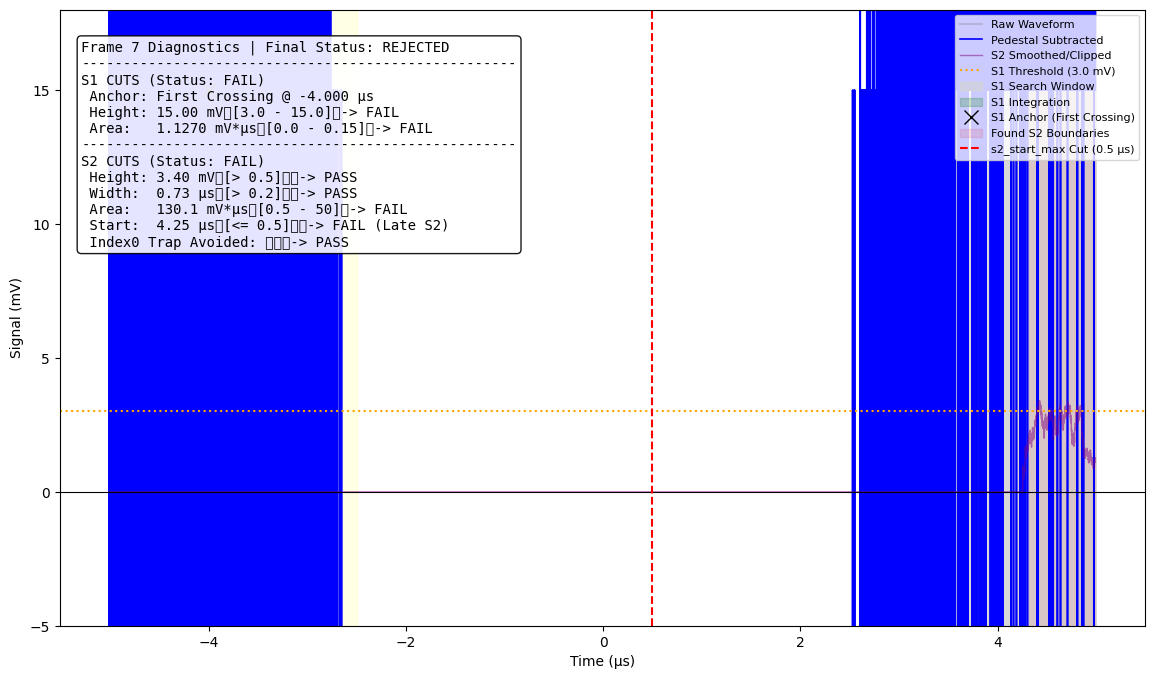

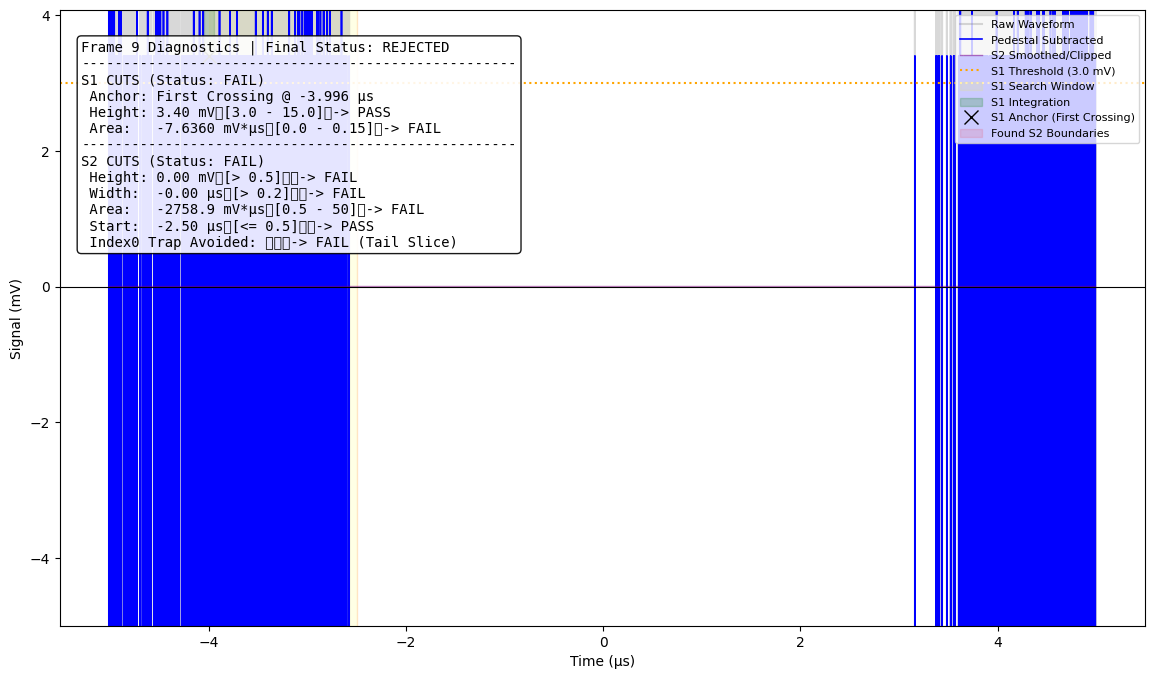

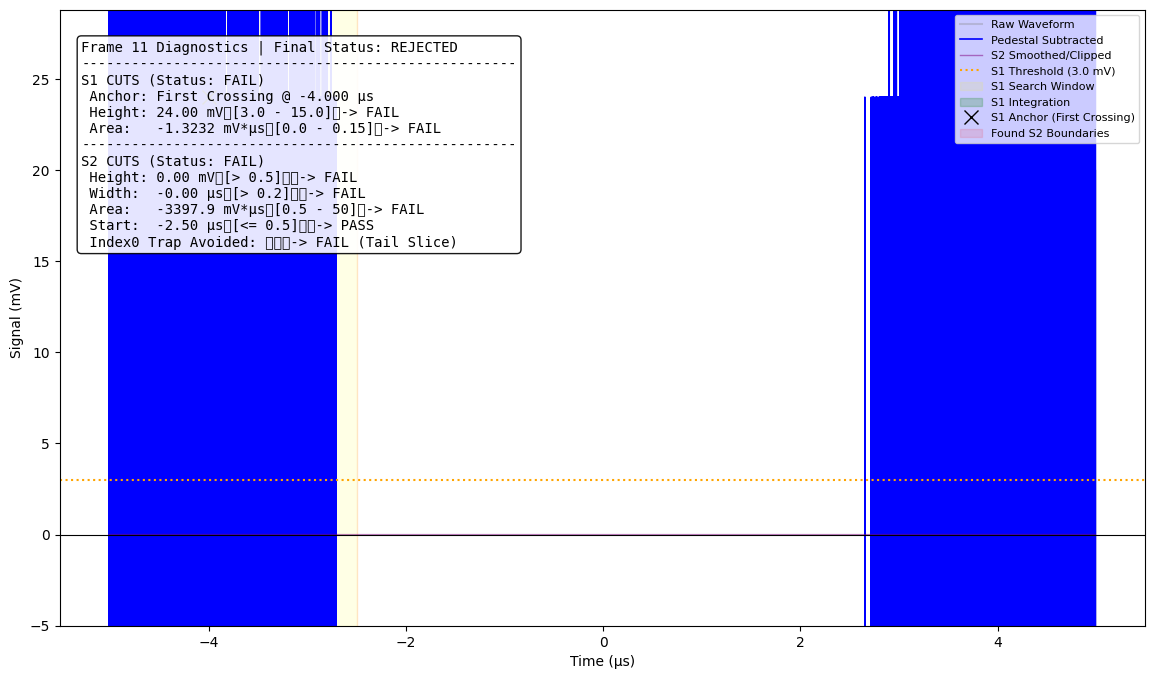

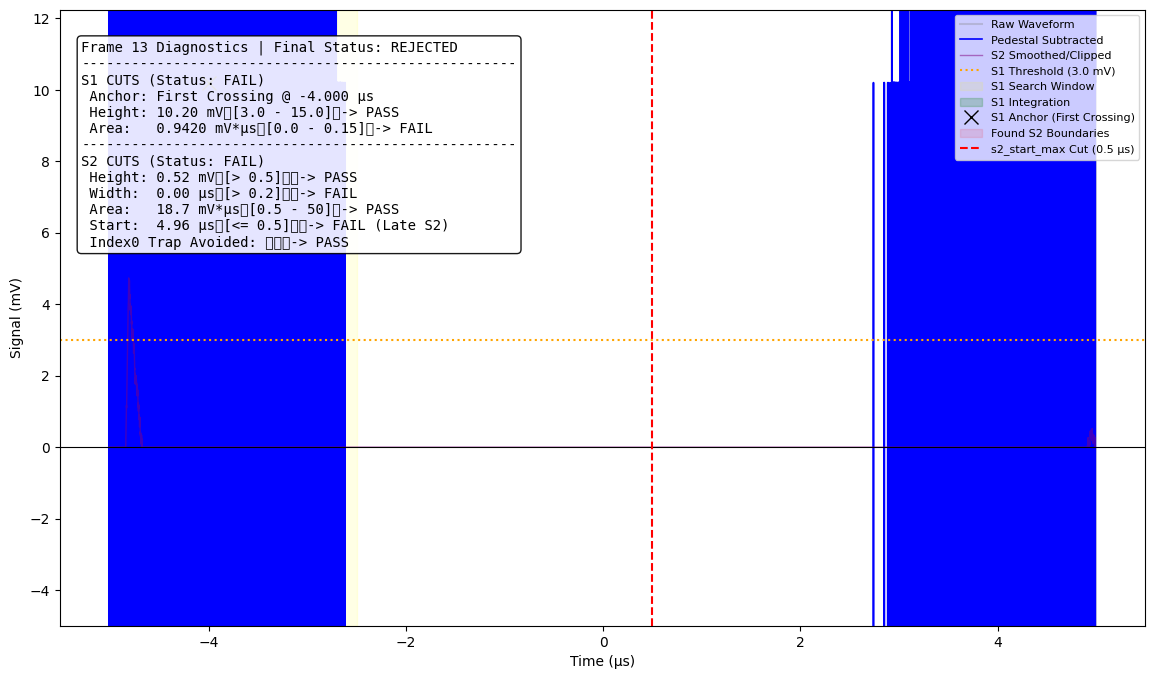

In [19]:
for uid in uids[:5]:
    wf, frame_idx = load_waveform_by_uid(set9, uid)
    wf = extract_single_frame(wf, frame_idx)
    # plot_waveform(wf, title=f"Waveform for UID {uid}")

    plot_full_coincidence_diagnostic(wf, config=TimingConfig(), frame_idx=frame_idx)

In [119]:
from RaTag.io.file_ops import load_yaml
config = load_yaml('/Users/pabloherrero/sabat/RaTagging/configs/recoils/run32_analysis.yaml')

In [121]:
config['preparation']

{'s1_t_min': -4.0,
 's1_t_max': -2.5,
 's1_v_min': 3.0,
 's1_v_max': 15.0,
 's1_max_area': 0.15,
 's2_margin': 0.9,
 's2_threshold': 0.5,
 's2_fraction': 0.05,
 's2_min_area': 0.5,
 's2_max_area': 50,
 's2_min_width': 0.2}